# Feature Engineering Playbook

## Business Context

Customer churn refers to customers who discontinue a service or stop doing business with a company.

Predicting churn enables businesses to proactively retain customers through targeted interventions such as discounts, support outreach, and contract incentives.

Reducing churn can significantly improve customer retention, customer lifetime value, and revenue stability.

---

## Objective

Predict customer churn using historical customer data.

---

## Business Question

Can we identify customers likely to leave the service before churn occurs?

---

## Notebook Scope

This notebook focuses on:

- understanding the dataset
- assessing data quality
- identifying feature engineering opportunities
- designing meaningful features
- evaluating the impact of engineered features

Simple baseline models may be used to measure feature effectiveness, but model selection and hyperparameter tuning are not the primary focus.

---

## Feature Engineering Mindset

Throughout this notebook, we will continuously ask:

> What business or behavioral signal does this feature capture?

The goal is not simply to transform columns, but to create useful feature representations that improve a model's ability to predict customer churn.

## Imports

In [1]:
# Standard library
import random

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local modules
from ml_playbook.config import DATA_DIR

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

## Configuration

In [2]:
# Constants
RANDOM_STATE = 42
TARGET_COL = "Churn"
TEST_SIZE = 0.25

# Paths
DATA_PATH = DATA_DIR / "customer_churn_fe_playbook.csv"

# Reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Data Loading and Initial Inspection

### Dataset Overview

The dataset contains customer demographic, service usage, billing, and account information along with a binary churn indicator.

Each row represents a unique customer.

### Target Variable:

- `Churn`
    - `1` → Customer churned
    - `0` → Customer retained

### Initial Dataset Inspection

In this section, we load the dataset and perform a preliminary inspection to understand its size, structure, and feature types before conducting detailed exploratory analysis.


### Feature Summary

The dataset contains the following features:

- `gender` – customer gender
- `SeniorCitizen` – senior citizen indicator
- `tenure` – number of months with the company
- `MonthlyCharges` – monthly service charges
- `TotalCharges` – total amount billed to the customer
- `InternetService` – internet service type
- `Contract` – customer contract type
- `PaymentMethod` – payment method used
- `Churn` – customer churn indicator

In [3]:
df = pd.read_csv(DATA_PATH, header=0)
print(f"Shape: {df.shape}")

Shape: (1200, 9)


In [4]:
# Data types
df.dtypes

gender              object
SeniorCitizen        int64
tenure               int64
MonthlyCharges     float64
TotalCharges       float64
InternetService     object
Contract            object
PaymentMethod       object
Churn                int64
dtype: object

In [5]:
# Dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1200 non-null   object 
 1   SeniorCitizen    1200 non-null   int64  
 2   tenure           1200 non-null   int64  
 3   MonthlyCharges   1200 non-null   float64
 4   TotalCharges     1086 non-null   float64
 5   InternetService  1103 non-null   object 
 6   Contract         1200 non-null   object 
 7   PaymentMethod    1120 non-null   object 
 8   Churn            1200 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 84.5+ KB


### Observations

- The dataset contains customer-level records.
- Both numerical and categorical features are present.
- The target variable is `Churn`.
- Further assessment of missing values, duplicates, and data consistency is required before feature engineering.

## Understand Features and Business Meaning

### Business Interpretation

The dataset contains a mix of:

- demographic information
- customer account information
- billing information
- service-related information

Together, these features provide multiple perspectives on customer behavior and may help explain why customers choose to remain with or leave the service.

---

### Analysis Objectives

Before performing detailed analysis, we want to understand:

- Which features appear likely to contain useful churn-related signals?
- Which customer characteristics may influence retention?
- Are there data quality issues that require preprocessing?
- What feature engineering opportunities exist within the dataset?

---

### Observations

- The dataset contains both numerical and categorical features.
- Features span multiple business domains, including customer demographics, account information, billing, and services.
- Several features appear likely to contain signals relevant to churn prediction.
- Further exploratory analysis is required before drawing conclusions about feature usefulness.

### Dataset Structure and Summary Statistics

In [6]:
feature_columns = [
    col for col in df.columns
    if col != TARGET_COL
]

### Feature Groups

Identify numerical and categorical features for downstream preprocessing and feature engineering.

In [7]:
# Features treated as categorical despite numeric storage
categorical_overrides = ["SeniorCitizen"]

# Numerical features
numerical_features = df[feature_columns].select_dtypes(
    include=np.number
).columns.tolist()

numerical_features = [
    col
    for col in numerical_features
    if col not in categorical_overrides
]

# Categorical features
categorical_features = df[feature_columns].select_dtypes(
    exclude=np.number
).columns.tolist()

categorical_features.extend(
    categorical_overrides
)

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'InternetService', 'Contract', 'PaymentMethod', 'SeniorCitizen']


### Numerical Features

Review summary statistics for numerical features to understand value ranges, central tendency, and potential anomalies.

In [8]:
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,1200.000000,1200.000000,1086.000000
mean,35.768333,71.536025,2542.810138
std,20.800927,29.009536,1940.867966
min,1.000000,18.000000,-451.660000
25%,17.000000,51.317500,1008.590000
50%,35.000000,71.170000,2199.740000
75%,54.000000,90.860000,3714.115000
max,72.000000,150.000000,9820.930000


### Categorical Features

Review summary statistics for categorical features to understand category cardinality and dominant categories.

In [9]:
df[categorical_features].describe(include="all")

,gender,InternetService,Contract,PaymentMethod,SeniorCitizen
count,1200,1103,1200,1120,1200.000000
unique,2,3,3,4,NaN
top,Female,Fiber optic,Month-to-month,Mailed check,NaN
freq,604,493,626,288,NaN
mean,NaN,NaN,NaN,NaN,0.155833
std,NaN,NaN,NaN,NaN,0.362848
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,0.000000


### Observations

- The dataset contains a mix of numerical and categorical features.
- Numerical features span different value ranges and may require further distribution analysis.
- Categorical features contain a small number of unique categories, making them suitable for standard encoding techniques.
- Missing values are already visible in several features and will require further investigation.
- Feature groups have been identified for downstream preprocessing and feature engineering.

## Target Variable Analysis

The target variable is:

- `Churn`
    - `1` → Customer churned
    - `0` → Customer retained

In [10]:
df[TARGET_COL].value_counts()

Churn
0    656
1    544
Name: count, dtype: int64

In [11]:
df[TARGET_COL].value_counts(normalize=True)

Churn
0    0.546667
1    0.453333
Name: proportion, dtype: float64

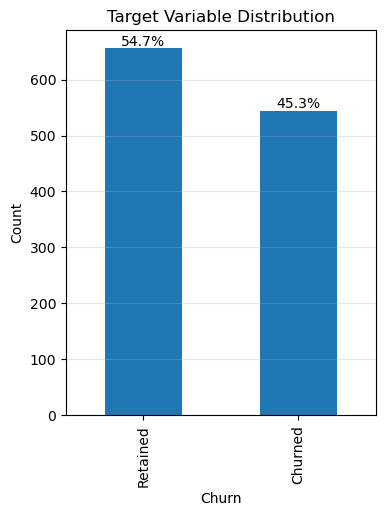

In [12]:
# Target distribution
target_counts = df[TARGET_COL].value_counts().sort_index()
target_percentages = (
    df[TARGET_COL]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

fig, ax = plt.subplots(figsize=(4, 5))

target_counts.plot(
    kind="bar",
    ax=ax
)

# Add percentage labels
for i, pct in enumerate(target_percentages):
    ax.text(
        i,
        target_counts.iloc[i],
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_title("Target Variable Distribution")
ax.set_xticklabels(["Retained", "Churned"])
ax.set_ylabel("Count")

ax.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- The target variable is reasonably balanced, with both classes well represented.
- Approximately 54.7% of customers were retained, while 45.3% churned.
- No severe class imbalance is observed at this stage.
- The presence of a substantial number of churned customers should enable meaningful analysis of churn-related patterns.
- Both classes contain enough observations to support downstream feature engineering and model development.

## Duplicate Record Analysis

In [13]:
duplicate_count = df.duplicated().sum()
duplicate_pct = df.duplicated().mean() * 100

print(f"Number of rows: {len(df):,}")
print(f"Number of duplicates: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")

Number of rows: 1,200
Number of duplicates: 0
Duplicate percentage: 0.00%


### Observations

- No duplicate records were identified in the dataset.
- Each row appears to represent a unique customer record.
- Duplicate-related data quality issues are not a concern for this dataset.
- Duplicate validation remains an important step in the initial data quality assessment process.

## Missing Value Analysis

In [14]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean()* 100
        ).round(2)
})

missing_summary = (
    missing_summary
    .loc[missing_summary["Missing_Count"] > 0]
    .sort_values(
        by="Missing_Count",
        ascending=False
    )
)

missing_summary

,Missing_Count,Missing_Percentage
TotalCharges,114,9.50
InternetService,97,8.08
PaymentMethod,80,6.67


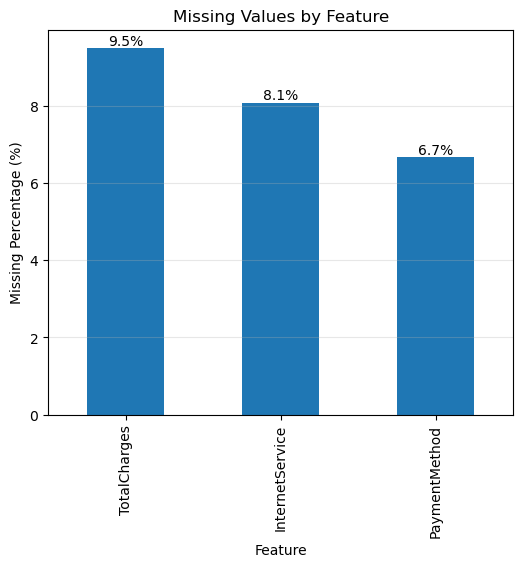

In [15]:
# Mssing Value distribution
missing_percentages = missing_summary["Missing_Percentage"]

fig, ax = plt.subplots(figsize=(6, 5))

missing_percentages.plot(
    kind="bar",
    ax=ax
)

# Add percentage labels
for i, pct in enumerate(missing_percentages):
      ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_title("Missing Values by Feature")
ax.set_xlabel("Feature")
ax.set_ylabel("Missing Percentage (%)")

ax.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- Missing values are present in three features: `TotalCharges`, `InternetService`, and `PaymentMethod`.
- `TotalCharges` contains the highest proportion of missing values (9.5%).
- Both numerical and categorical features contain missing values.
- Missing value treatment will be required before model training.
- The causes of missingness should be investigated before selecting an imputation strategy.

## Numerical Feature Exploration

Numerical feature distributions can reveal:

- skewness
- unusual values
- potential outliers
- transformation opportunities

The goal is to identify potential data quality issues and feature engineering opportunities before preprocessing.

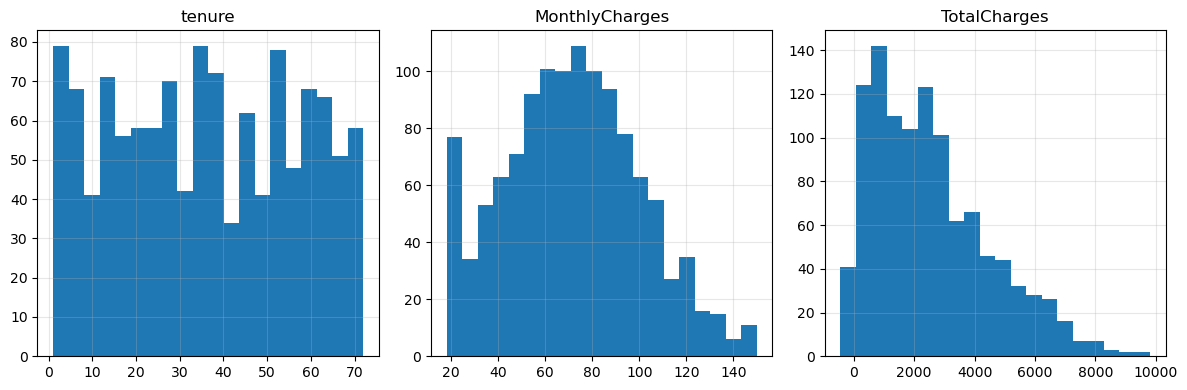

In [16]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(numerical_features),
    figsize=(12, 4)
)

for ax, feature in zip(axes, numerical_features):

    ax.hist(
        df[feature].dropna(),
        bins=20
    )

    ax.set_title(feature)
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

### Distribution Review

#### tenure

- Customers span both short and long tenures.
- The distribution covers multiple customer lifecycle stages.
- Tenure is likely to be an important churn-related feature.

#### MonthlyCharges

- Monthly charges span a wide range of values.
- The distribution appears moderately concentrated around the middle charge ranges.
- Multiple service plans or pricing tiers may be contributing to the observed distribution.

#### TotalCharges

- The distribution is strongly right-skewed.
- Most customers have relatively low-to-moderate total charges, while a smaller number have very large values.
- The long right tail suggests that transformations may be worth evaluating during feature engineering.
- The presence of negative values is unexpected and requires further investigation.

### Observations

- Numerical feature distributions vary substantially across the dataset.
- `tenure` spans both newer and long-term customers, indicating representation across different stages of the customer lifecycle.
- `MonthlyCharges` exhibits a broad distribution, suggesting the presence of multiple pricing tiers or service plans.
- `TotalCharges` is strongly right-skewed, with a small number of customers accumulating substantially higher charges than the majority.
- The presence of unexpected negative values in `TotalCharges` requires further investigation.
- `TotalCharges` is likely related to both `tenure` and `MonthlyCharges`, suggesting opportunities for derived, interaction, or ratio-based features in later stages of the notebook.

### Investigation: Negative Total Charges

The summary statistics and distribution plots revealed that `TotalCharges` contains negative values.

Because total customer charges are generally expected to be non-negative, these records require further investigation.

The objective is to determine:

- how many negative values exist
- whether they appear consistent with expected business behavior
- whether additional investigation is required

In [17]:
# Records with negative total charges
negative_total_charges = df.loc[
    df["TotalCharges"] < 0
]

negative_pct = (
    len(negative_total_charges)
    / len(df)
    * 100
)

print(
    f"Negative TotalCharges Records: {len(negative_total_charges)}\n"
    f"Negative TotalCharges Percent: {negative_pct:.2f}%"
)

negative_total_charges.head()

Negative TotalCharges Records: 29
Negative TotalCharges Percent: 2.42%


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,InternetService,Contract,PaymentMethod,Churn
12,Female,0,2,83.80,-319.18,DSL,One year,NaN,0
87,Female,0,5,51.89,-10.21,DSL,One year,Electronic check,0
140,Male,0,3,79.85,-166.03,Fiber optic,Month-to-month,Mailed check,1
240,Male,0,20,21.45,-14.42,Fiber optic,Two year,Mailed check,0
253,Female,0,8,24.62,-54.86,Fiber optic,Month-to-month,Credit card,1


### Observations

- Multiple records contain negative values for `TotalCharges`.
- Negative charges are not generally expected from a business perspective and may indicate:
    - refunds or billing adjustments
    - data entry issues
    - synthetic data generation artifacts
- The cause of the negative values cannot be determined from the current analysis alone and would require additional domain knowledge.
- These records should be considered during future preprocessing and feature engineering decisions.

## Categorical Feature Exploration

Understanding category distributions can help identify:

- dominant categories
- rare categories
- potential encoding requirements
- grouping opportunities
- feature engineering opportunities

The goal is to understand category distributions and identify potential encoding, grouping, and feature engineering opportunities.

In [18]:
for feature in categorical_features:
    
    print('=' * 50)

    display(
    pd.DataFrame({
        "Count": df[feature].value_counts(dropna=False),
        "Percentage": (
            df[feature]
            .value_counts(normalize=True, dropna=False)
            * 100
        ).round(2)
    })
)

,Count,Percentage
gender,,
Female,604,50.33
Male,596,49.67


,Count,Percentage
InternetService,,
Fiber optic,493,41.08
DSL,457,38.08
No,153,12.75
NaN,97,8.08


,Count,Percentage
Contract,,
Month-to-month,626,52.17
One year,326,27.17
Two year,248,20.67


,Count,Percentage
PaymentMethod,,
Mailed check,288,24.00
Bank transfer,278,23.17
Electronic check,277,23.08
Credit card,277,23.08
NaN,80,6.67


,Count,Percentage
SeniorCitizen,,
0,1013,84.42
1,187,15.58


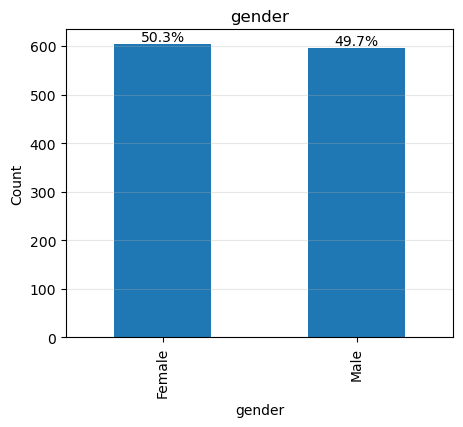

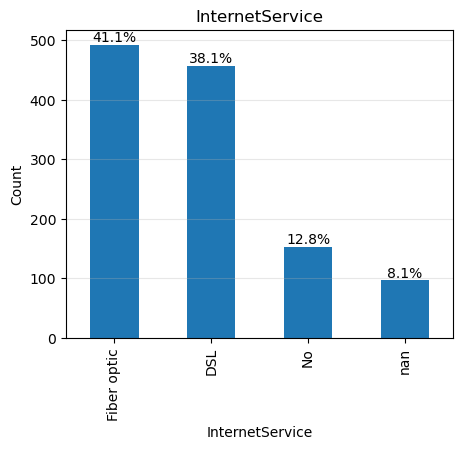

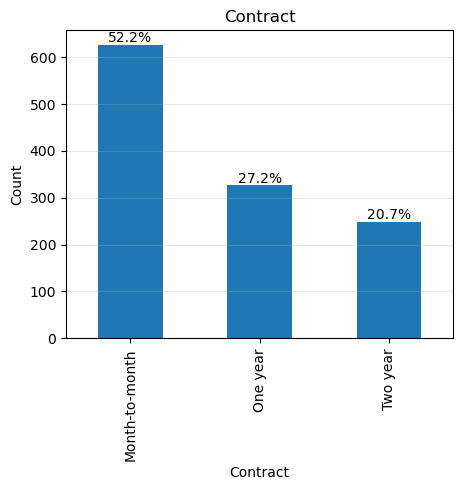

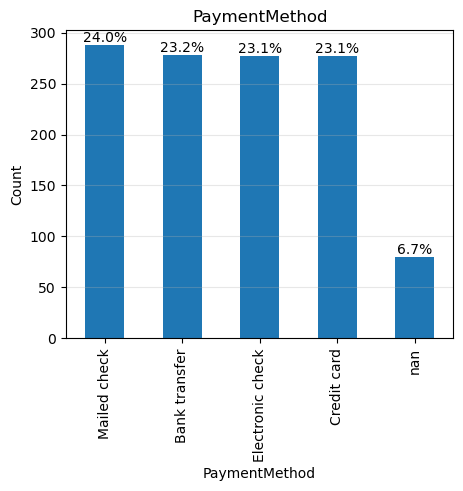

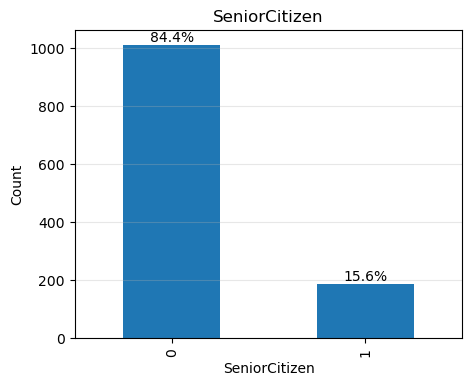

In [19]:
for feature in categorical_features:

    counts = (
        df[feature]
        .value_counts(dropna=False)
    )

    percentages = (
        df[feature]
        .value_counts(normalize=True, dropna=False)
        * 100
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    counts.plot(
        kind="bar",
        ax=ax
    )

    # Add percentage labels
    for i, pct in enumerate(percentages):
        ax.text(
            i,
            counts.iloc[i],
            f"{pct:.1f}%",
            ha="center",
            va="bottom"
        )

    ax.set_title(feature)
    ax.set_ylabel("Count")

    ax.grid(axis="y", alpha=0.3)

    plt.show()

### Feature Review

#### gender

- The distribution appears reasonably balanced across customer records.
- No obvious data quality concerns are observed.

#### SeniorCitizen

- Senior citizens represent a smaller customer segment.
- The feature may capture differences in service usage or retention behavior.

#### InternetService

- Multiple service offerings are represented.
- Service type may influence customer experience and retention.

#### Contract

- Multiple contract structures are present.
- Contract duration may influence customer commitment and service continuity.

#### PaymentMethod

- Multiple payment methods are represented.
- Payment behavior may reflect different customer preferences and engagement patterns.

### Observations

- Several categorical features represent meaningful business processes rather than simple customer attributes.
- Most categorical features exhibit low cardinality and should be straightforward to encode.
- Contract type, payment method, and internet service appear particularly relevant from a business and customer-behavior perspective.
- Missing values are present in certain categorical features and may require dedicated treatment during preprocessing.
- Certain features may present opportunities for grouping or business-driven feature engineering.
- No severe category sparsity issues are observed at this stage.

## Initial Feature Engineering Opportunities

### Purpose

The exploratory analysis identified several potential opportunities to improve the quality and usefulness of the feature set.

The objective of this section is to translate those findings into candidate feature engineering strategies that can be evaluated in later stages of the notebook.

These opportunities are currently hypotheses and will require implementation and validation before determining their impact on model performance.

---

### Missing Value Opportunities

Several features contain missing values, including:

- `TotalCharges`
- `InternetService`
- `PaymentMethod`

Potential approaches include:

- numerical imputation for missing continuous values
- categorical imputation for missing categories
- missing value indicators to capture potential missingness patterns

---

### Numerical Feature Opportunities

#### tenure

Potential opportunities:

- customer lifecycle segmentation
- tenure-based binning
- new vs established customer indicators

#### TotalCharges

Potential opportunities:

- skewness-aware transformations
- handling of unexpected negative values
- derived billing-related features

#### MonthlyCharges

Potential opportunities:

- spending-based customer segmentation
- interaction with customer tenure
- customer value representations

---

### Categorical Feature Opportunities

#### Contract

Potential opportunities:

- categorical encoding
- contract risk segmentation
- business-driven grouping strategies

#### PaymentMethod

Potential opportunities:

- categorical encoding
- missing value treatment
- payment behavior indicators

#### InternetService

Potential opportunities:

- categorical encoding
- service-level grouping strategies
- interaction with billing-related features

#### SeniorCitizen

Potential opportunities:

- interaction with service and billing features

---

### Derived Feature Opportunities

The exploratory analysis suggests that certain features may contain meaningful relationships.

Potential candidates include:

- billing-related interaction features
- tenure-adjusted spending features
- customer value indicators
- ratio-based features derived from account and billing information

In particular, `TotalCharges` appears likely to be related to both `tenure` and `MonthlyCharges`, suggesting opportunities for business-driven feature creation.

---

### Leakage Considerations

Feature engineering should be performed using information available at prediction time.

Potential future risks include:

- creating features that indirectly use target information
- using information unavailable during inference
- introducing train-test contamination during preprocessing

Leakage prevention will be explicitly evaluated in later sections of the notebook.

---

### Observations

- Multiple opportunities for feature engineering were identified during exploratory analysis.
- Missing value treatment is likely to play an important role in the preprocessing workflow.
- Several categorical features appear well suited for encoding and business-driven transformations.
- Numerical features present opportunities for transformation, segmentation, and derived feature creation.
- Relationships between billing and tenure-related features may provide useful predictive signals.
- All feature engineering ideas should ultimately be validated using downstream model performance.


## Key Findings and Next Steps

### Key Findings

- The dataset contains a mix of numerical and categorical features spanning customer demographics, account information, billing, and service-related attributes.
- Missing values are present in both numerical and categorical features and will require appropriate treatment during preprocessing.
- No duplicate records were identified in the dataset.
- `TotalCharges` contains unexpected negative values that require further investigation and preprocessing decisions.
- Numerical feature exploration revealed opportunities for transformation, segmentation, and derived feature creation.
- Several categorical features, particularly `Contract`, `PaymentMethod`, and `InternetService`, appear likely to contain meaningful business signals.
- Relationships between billing-related features and customer tenure suggest opportunities for interaction, ratio-based, and business-driven feature engineering.
- Multiple feature engineering opportunities were identified, but their usefulness must be validated through downstream model performance.

---

### Next Steps

The next stage of the notebook will focus on establishing a baseline modeling pipeline, including:

- train-test splitting
- missing value treatment
- categorical encoding
- feature scaling where appropriate
- baseline logistic regression modeling

The baseline model will provide a reference point for evaluating the impact of future feature engineering decisions.


## Train-Test Split

Before any preprocessing or modeling, the dataset is divided into separate training and test sets.

This helps ensure that model performance is evaluated on unseen data and provides a realistic estimate of how the model may perform in production.

- Training set: used for preprocessing, feature engineering, and model training
- Test set: used only for final model evaluation

In [20]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

In [21]:
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape : {X_test.shape}")

X_train Shape: (900, 8)
X_test Shape : (300, 8)


In [22]:
class_distribution = pd.DataFrame({
    "Train (%)": (
        y_train
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2),
    "Test (%)": (
        y_test
        .value_counts(normalize=True)
        .sort_index()
        * 100
    ).round(2)
})

class_distribution.index.name = "Class"

class_distribution

,Train (%),Test (%)
Class,,
0,54.67,54.67
1,45.33,45.33


### Observations

- The dataset was split into 900 training records and 300 testing records (80/20 split).
- The class distribution is nearly identical across the training and test sets.
- Stratified sampling successfully preserved the target class proportions.
- The datasets appear suitable for subsequent preprocessing, modeling, and evaluation.

## Baseline Preprocessing Strategy

Before training a baseline model, a preprocessing strategy must be defined.

The objective is to establish a simple, reproducible preprocessing strategy that serves as a reference point for future feature engineering experiments.

---

### Numerical Features

Numerical features will undergo:

- missing value imputation
- standardization

---

### Categorical Features

Categorical features will undergo:

- missing value imputation
- one-hot encoding

---

### Rationale

The baseline model uses logistic regression, which:

- requires numerical inputs
- is sensitive to feature scale

Therefore:

- categorical features will be converted using one-hot encoding
- numerical features will be standardized
- simple imputation strategies will be used for missing values

More advanced preprocessing techniques may be evaluated in later experiments if justified by feature characteristics or model performance.bm

---

### Observations

- A simple preprocessing strategy has been selected for the baseline model.
- The chosen approach prioritizes interpretability and reproducibility over optimization.
- Future feature engineering experiments will be evaluated against this baseline.


## Missing Value Imputation

Before training a baseline model, missing values must be handled because most machine learning algorithms cannot work with incomplete data.

The objective of this section is to implement a simple missing value treatment strategy while preserving all available records.

### Numerical Feature Imputation

In [23]:
# Numerical imputer
numerical_imputer = SimpleImputer(
    strategy="median"
)

X_train_num_imputed = pd.DataFrame(
    numerical_imputer.fit_transform(
        X_train[numerical_features]
    ),
    columns=numerical_features,
    index=X_train.index
)

X_test_num_imputed = pd.DataFrame(
    numerical_imputer.transform(
        X_test[numerical_features]
    ),
    columns=numerical_features,
    index=X_test.index
)

### Categorical Feature Imputation

In [24]:
# Categorical imputer
categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_train_cat_imputed = pd.DataFrame(
    categorical_imputer.fit_transform(
        X_train[categorical_features]
    ),
    columns=categorical_features,
    index=X_train.index
)

X_test_cat_imputed = pd.DataFrame(
    categorical_imputer.transform(
        X_test[categorical_features]
    ),
    columns=categorical_features,
    index=X_test.index
)

### Imputation Summary

Review the values used for imputation and verify that no missing values remain after preprocessing.

#### Numerical Imputation Values

In [25]:
pd.DataFrame(
    {
        "Imputation_Value": numerical_imputer.statistics_
    },
    index=numerical_features
).round(2)

,Imputation_Value
tenure,35.50
MonthlyCharges,69.66
TotalCharges,2157.92


#### Categorical Imputation Values

In [26]:
pd.DataFrame(
    {
        "Imputation_Value": categorical_imputer.statistics_
    },
    index=categorical_features
)

,Imputation_Value
gender,Female
InternetService,Fiber optic
Contract,Month-to-month
PaymentMethod,Bank transfer
SeniorCitizen,0


#### Note

Imputation statistics were computed using the training dataset only and then applied to both training and test data.

This prevents information leakage from the test set into the training process.

### Missing Value Verification

In [27]:
pd.DataFrame({
    "Remaining Missing Values": [
        X_train_num_imputed.isnull().sum().sum(),
        X_test_num_imputed.isnull().sum().sum(),
        X_train_cat_imputed.isnull().sum().sum(),
        X_test_cat_imputed.isnull().sum().sum()
    ]
},
index=[
    "Train Numerical",
    "Test Numerical",
    "Train Categorical",
    "Test Categorical"
])

,Remaining Missing Values
Train Numerical,0
Test Numerical,0
Train Categorical,0
Test Categorical,0


### Observations

- Missing values were successfully imputed in both numerical and categorical features.
- Numerical features were imputed using median values computed from the training data.
- Categorical features were imputed using the most frequent category observed in the training data.
- No missing values remain in either the training or test datasets after imputation.
- Imputation statistics were learned from the training data only, helping prevent information leakage.
- The datasets are now ready for categorical encoding and feature scaling.

## Categorical Feature Encoding

Machine learning algorithms require numerical inputs.

The objective of this section is to convert categorical features into a numerical representation suitable for logistic regression.

---

### Why One-Hot Encoding?

Several encoding strategies exist, including:

- One-Hot Encoding
- Ordinal Encoding
- Target Encoding
- Frequency Encoding

For the baseline model, One-Hot Encoding is selected because:

- most categorical features in this dataset represent distinct categories rather than continuous rankings
- it avoids imposing potentially incorrect numerical relationships between categories
- it is easy to interpret and widely used in baseline classification models
- it is well suited for logistic regression

Alternative encoding strategies may be evaluated in later experiments if justified by feature characteristics or model performance.

### Apply One-Hot Encoding

#### Encoder Configuration

The encoder is configured with:

- `handle_unknown="ignore"` to prevent errors when previously unseen categories appear during inference.
- `sparse_output=False` to return a dense array, making the encoded output easier to inspect within the notebook.

For large-scale production workflows, `sparse_output=True` is often preferred because one-hot encoded datasets typically contain many zeros and sparse storage is more memory efficient.

In [28]:
# One-Hot Encoder
onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat_encoded = pd.DataFrame(
    onehot_encoder.fit_transform(
        X_train_cat_imputed
    ),
    columns=onehot_encoder.get_feature_names_out(),
    index=X_train_cat_imputed.index
)

X_test_cat_encoded = pd.DataFrame(
    onehot_encoder.transform(
        X_test_cat_imputed
    ),
    columns=onehot_encoder.get_feature_names_out(),
    index=X_test_cat_imputed.index
)

### Encoded Feature Summary

In [29]:
# Number of generated features before vs after encoding
print(f"Original Categorical Features: {len(categorical_features)}")
print(f"Encoded Features: {X_train_cat_encoded.shape[1]}")
print(f"Additional Features Created: {X_train_cat_encoded.shape[1] - len(categorical_features)}")

Original Categorical Features: 5
Encoded Features: 14
Additional Features Created: 9


In [30]:
# Encoded feature names
X_train_cat_encoded.columns.tolist()

['gender_Female',
 'gender_Male',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Bank transfer',
 'PaymentMethod_Credit card',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'SeniorCitizen_0',
 'SeniorCitizen_1']

In [31]:
# Inspect few samples of the encoded dataset
X_train_cat_encoded.head(2)

,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_0,SeniorCitizen_1
776,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
772,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### Observations

- One-hot encoding successfully converted all categorical features into a numerical representation.
- The encoding expanded the feature space from 5 categorical features to 14 encoded features.
- The encoded dataset is now suitable for logistic regression and other machine learning algorithms that require numerical inputs.
- Additional encoding strategies may be explored in future experiments if warranted by feature characteristics or model performance. 
- No information was lost during encoding, as each category was represented by its own indicator feature.

## Feature Scaling

The baseline model uses logistic regression, which is sensitive to feature scale.

To ensure comparable feature magnitudes, numerical features will be standardized using `StandardScaler` before model training.

Alternative scaling strategies may be evaluated in future experiments if needed.

### Apply Standardization

In [32]:
# Standard scaler
scaler = StandardScaler()

X_train_num_scaled = pd.DataFrame(
    scaler.fit_transform(
        X_train_num_imputed
    ),
    columns=numerical_features,
    index=X_train_num_imputed.index
)

X_test_num_scaled = pd.DataFrame(
    scaler.transform(
        X_test_num_imputed
    ),
    columns=numerical_features,
    index=X_test_num_imputed.index
)

### Scaling Verification

In [33]:
# Verify scaling on training data
X_train_num_scaled.describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,900.00,900.00,900.00
mean,-0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.67,-1.82,-1.59
25%,-0.90,-0.72,-0.76
50%,-0.00,-0.03,-0.17
75%,0.89,0.64,0.50
max,1.76,2.76,3.71


In [34]:
# Inspect few samples of the scaled dataset
X_train_num_scaled.head(2)

,tenure,MonthlyCharges,TotalCharges
776,1.372627,-0.144900,0.706479
772,-1.137099,0.404148,-0.544959


### Observations

- Numerical features were standardized using statistics learned from the training dataset and then applied to both training and test data.
- The scaled training features have means close to 0 and standard deviations close to 1, confirming that standardization was applied correctly.
- Feature scaling places numerical variables on comparable magnitudes, which is beneficial for logistic regression.
- The scaled datasets are now suitable for downstream model training and evaluation.

## Prepare Modeling Dataset

The processed numerical and categorical features are combined to create the final datasets used for model training and evaluation.

### Combine Processed Features

In [35]:
# Final training dataset
X_train_processed = pd.concat(
    [
        X_train_num_scaled,
        X_train_cat_encoded
    ],
    axis=1
)

# Final test dataset
X_test_processed = pd.concat(
    [
        X_test_num_scaled,
        X_test_cat_encoded
    ],
    axis=1
)

### Dataset Verification

In [36]:
print(f"Training Shape: {X_train_processed.shape}")
print(f"Test Shape: {X_test_processed.shape}")

Training Shape: (900, 17)
Test Shape: (300, 17)


In [37]:
# Processed dataset feature names
X_train_processed.columns.tolist()

['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Female',
 'gender_Male',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Bank transfer',
 'PaymentMethod_Credit card',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'SeniorCitizen_0',
 'SeniorCitizen_1']

In [38]:
# Inspect few samples of the processed dataset
X_train_processed.head(2)

,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check,SeniorCitizen_0,SeniorCitizen_1
776,1.372627,-0.144900,0.706479,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
772,-1.137099,0.404148,-0.544959,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### Observations

- Numerical and categorical preprocessing outputs were successfully combined into unified modeling datasets.
- The training dataset contains 900 records and 17 processed features, while the test dataset contains 300 records and 17 processed features.
- Numerical features are standardized, while categorical features are represented using one-hot encoded indicator variables.
- The processed datasets contain only numerical values and are suitable for machine learning model training.
- The preprocessing pipeline is now complete, allowing baseline model development to begin.

## Baseline Logistic Regression Model

A baseline logistic regression model is trained to establish a reference point for evaluating future feature engineering experiments.

In [39]:
lr_baseline = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

### Model Training

In [40]:
lr_baseline.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Model Predictions

In [41]:
y_pred = lr_baseline.predict(X_test_processed)
y_prob = lr_baseline.predict_proba(X_test_processed)[:, 1]

In [42]:
# Metrics
lr_baseline_roc_auc = roc_auc_score(y_test, y_prob)
lr_baseline_accuracy = accuracy_score(y_test, y_pred)
lr_baseline_precision = precision_score(y_test, y_pred)
lr_baseline_recall = recall_score(y_test, y_pred)
lr_baseline_f1 = f1_score(y_test, y_pred)

# Confusion matrix
lr_baseline_cm = confusion_matrix(y_test, y_pred)

### Baseline Model Evaluation

In [43]:
# Metrics
baseline_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        lr_baseline_roc_auc,
        lr_baseline_accuracy,
        lr_baseline_precision,
        lr_baseline_recall,
        lr_baseline_f1
    ]
})

baseline_metrics["Score"] = baseline_metrics["Score"].round(3)

baseline_metrics

,Metric,Score
0,ROC-AUC,0.736
1,Accuracy,0.697
2,Precision,0.696
3,Recall,0.588
4,F1-Score,0.637


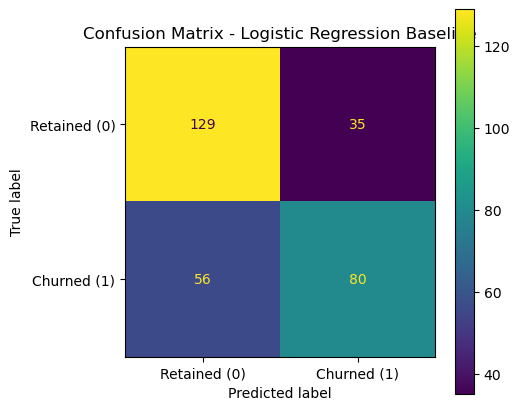

In [44]:
# Display confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay(
    confusion_matrix=lr_baseline_cm,
    display_labels=["Retained (0)", "Churned (1)"]
).plot(ax=ax)
ax.set_title("Confusion Matrix - Logistic Regression Baseline")

plt.show()

### Confusion Matrix Insights

- The model correctly identifies `129` retained customers (True Negatives).
- The model correctly identifies `80` churned customers (True Positives).
- `35` retained customers are incorrectly predicted as churners (False Positives).
- `56` churned customers are missed and incorrectly predicted as retained (False Negatives).

The model misses more churners than it incorrectly flags as churners, which contributes to the lower Recall score.

Because retaining existing customers is often a key business objective, reducing false negatives may be particularly important in future iterations.

### Observations

- The baseline logistic regression model achieves a ROC-AUC of 0.736, indicating moderate ability to distinguish between churned and retained customers.
- Precision exceeds Recall, suggesting that the model is relatively conservative when predicting churn.
- The model correctly identifies many churners, but still misses a substantial number of customers who ultimately leave the service.
- False negatives represent a key area for improvement because missed churners may correspond to lost retention opportunities.
- These results establish a baseline against which future preprocessing and feature engineering experiments can be compared.

### Baseline Assessment

The baseline model demonstrates that the available features contain meaningful predictive signal.

However, the current performance also suggests that there is room for improvement.

Future feature engineering efforts may focus on:

- improving the representation of customer tenure and billing behavior
- exploring interactions between related features
- evaluating alternative preprocessing strategies
- reducing the number of missed churners

Any future modifications should be evaluated against this baseline to determine whether they provide measurable improvements.

## Summary and Next Steps

### Key Findings

- A baseline preprocessing workflow was established using imputation, one-hot encoding, and feature standardization.
- The final modeling dataset contains 17 processed features derived from both numerical and categorical variables.
- The baseline logistic regression model achieved a ROC-AUC of 0.736.
- The model demonstrates that the available customer, billing, and service features contain meaningful predictive signal.
- Precision exceeds Recall, indicating that a substantial number of churned customers are still missed.
- The current results establish a benchmark for evaluating future feature engineering experiments.

---

### Baseline Reference Metrics

| Metric | Score |
|----------|----------|
| ROC-AUC | 0.736 |
| Accuracy | 0.697 |
| Precision | 0.696 |
| Recall | 0.588 |
| F1-Score | 0.637 |

These metrics will serve as the reference point for future experiments.

---

### Next Steps

The next stage of the notebook will focus on feature engineering.

Areas for investigation include:

- billing-related feature relationships
- tenure-based customer segmentation
- interaction features
- ratio-based features
- alternative preprocessing strategies
- treatment of anomalous values

Each proposed feature engineering technique will be evaluated against the current baseline to determine whether it produces measurable improvements in model performance.

---

### Conclusion

The baseline model confirms that the dataset contains useful predictive information. However, the current performance indicates that additional improvements may be achievable through better feature representation and feature engineering.

Future experiments should be guided by measurable improvements relative to the baseline established in this commit.

## Feature Engineering Strategy

The baseline model established that the dataset contains meaningful predictive signal. However, the current performance suggests that additional improvements may be achievable through better feature representation.

The objective of this section is to create new features that better capture customer behavior, billing patterns, and business relationships that may not be fully represented by the original variables.

Unlike preprocessing steps such as imputation, encoding, and scaling, feature engineering focuses on creating new information from existing data.

All engineered features will be evaluated against the baseline model established in the previous commit.

---

### Guiding Principles

Feature engineering should be driven by:

- business understanding
- customer behavior patterns
- domain knowledge
- observed relationships within the data

The goal is not to create as many features as possible, but to create features that capture meaningful predictive signals.

---

### Planned Experiments

This commit will focus on:

- missing value indicators
- customer lifecycle features
- billing-related derived features

Additional techniques such as interaction features, ratio features, binning, and outlier treatment will be evaluated in later stages of the notebook.

---

### Observations

- The baseline model provides a benchmark against which all engineered features can be evaluated.
- Feature engineering efforts will focus on improving feature representation rather than changing the underlying model.
- Any proposed feature should be justified by either business reasoning, observed data patterns, or measurable improvements in model performance.

## Missingness as Signal

Missing values do not always represent random data quality issues.

In some cases, the presence of a missing value may itself contain useful information about customer behavior, business processes, or data collection patterns.

Creating missing value indicator features allows the model to explicitly learn whether the presence of missing information is associated with customer churn.

---

### Potential Missingness Signals in This Dataset

Earlier analysis identified missing values in:

- `TotalCharges`
- `InternetService`
- `PaymentMethod`

These missing values may reflect:

- customer behavior patterns
- service configuration differences
- billing process variations
- data collection issues

Rather than immediately discarding this information through imputation, we can create indicator features that preserve the missingness pattern.

Examples:

- `TotalCharges_Missing`
- `InternetService_Missing`
- `PaymentMethod_Missing`

These features will take:

- `1` → original value was missing
- `0` → original value was present

---

### Observations

- Missing values may contain predictive information beyond the imputed values themselves.
- Missingness indicators allow the model to distinguish between observed and imputed records.
- Missingness indicators are commonly used in production systems because they can capture information that simple imputation alone may remove.
- This approach preserves potentially useful information that would otherwise be lost during imputation.
- The usefulness of missingness indicators will be evaluated relative to the baseline model.

## Missing Value Indicators

### Create Missing Indicators

Create binary indicator features that capture whether a value was originally missing.

These features preserve missingness information that would otherwise be lost after imputation.

Missing indicators are created before imputation so that the original missingness information is preserved.

In [45]:
missing_indicator_features = missing_summary.index.tolist()

for feature in missing_indicator_features:

    X_train[f"{feature}_Missing"] = (
        X_train[feature]
        .isnull()
        .astype(int)
    )

    X_test[f"{feature}_Missing"] = (
        X_test[feature]
        .isnull()
        .astype(int)
    )

### Indicator Summary

Review the prevalence of missing values captured by the newly created indicator features.

In [46]:
indicator_columns = [
    f"{feature}_Missing"
    for feature in missing_indicator_features
]

missing_indicator_summary = pd.DataFrame({
    "Train_Count": (
        X_train[indicator_columns].sum()
    ),

    "Train (%)": (
        X_train[indicator_columns].mean()* 100
    ).round(2),

    "Test_Count": (
        X_test[indicator_columns].sum()
    ),
    
    "Test (%)": (
        X_test[indicator_columns].mean()* 100
    ).round(2)
})

missing_indicator_summary

,Train_Count,Train (%),Test_Count,Test (%)
TotalCharges_Missing,77,8.56,37,12.33
InternetService_Missing,75,8.33,22,7.33
PaymentMethod_Missing,63,7.00,17,5.67


### Observations

- Missing value indicator features were successfully created for all features containing missing values.
- The indicators preserve information about whether a value was originally missing prior to imputation.
- Missingness rates are relatively similar between the training and test datasets, reducing concerns about distributional shifts in the indicator features.
- A meaningful proportion of records contain missing values, making missingness indicators reasonable candidates for feature engineering.
- These features allow the model to learn whether missingness itself is associated with customer churn.
- The impact of missingness indicators will be evaluated relative to the baseline model.

## Updated Modeling Dataset

The missing value indicators will now be incorporated into the processed modeling datasets so that the model can leverage both:

- imputed feature values
- missingness information

The objective is to evaluate whether preserving missingness information improves predictive performance relative to the baseline model.

### Add Missing Indicators to Processed Features

In [47]:
# Missing indicator features
X_train_missing_indicators = X_train[indicator_columns]

X_test_missing_indicators = X_test[indicator_columns]

# Updated training dataset
X_train_fe_v1 = pd.concat(
    [
        X_train_processed,
        X_train_missing_indicators
    ],
    axis=1
)

# Updated test dataset
X_test_fe_v1 = pd.concat(
    [
        X_test_processed,
        X_test_missing_indicators
    ],
    axis=1
)

### Dataset Verification

In [48]:
print(f"Baseline Features: {X_train_processed.shape[1]}")
print(f"Updated Features: {X_train_fe_v1.shape[1]}")
print(
    f"Additional Features Created: "
    f"{X_train_fe_v1.shape[1] - X_train_processed.shape[1]}"
)

Baseline Features: 17
Updated Features: 20
Additional Features Created: 3


### Observations

- Missing value indicator features were successfully incorporated into the modeling datasets.
- The feature space increased from 17 to 20 features.
- The updated datasets now contain both imputed feature values and explicit missingness information.
- The additional features capture information that was not available to the baseline model.
- The impact of these additional features will be evaluated relative to the baseline model.

## Feature Engineering Experiment: Missingness Indicators

In [49]:
lr_fe_v1 = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

### Model Training

In [50]:
lr_fe_v1.fit(X_train_fe_v1, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Model Predictions

In [51]:
y_pred_fe_v1 = lr_fe_v1.predict(X_test_fe_v1)
y_prob_fe_v1 = lr_fe_v1.predict_proba(X_test_fe_v1)[:, 1]

In [52]:
# Metrics
lr_fe_v1_roc_auc = roc_auc_score(y_test, y_prob_fe_v1)
lr_fe_v1_accuracy = accuracy_score(y_test, y_pred_fe_v1)
lr_fe_v1_precision = precision_score(y_test, y_pred_fe_v1)
lr_fe_v1_recall = recall_score(y_test, y_pred_fe_v1)
lr_fe_v1_f1 = f1_score(y_test, y_pred_fe_v1)

# Confusion matrix
lr_fe_v1_cm = confusion_matrix(y_test, y_pred_fe_v1)

### Feature Engineering Model Evaluation

In [53]:
# Metrics
fe_v1_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        lr_fe_v1_roc_auc,
        lr_fe_v1_accuracy,
        lr_fe_v1_precision,
        lr_fe_v1_recall,
        lr_fe_v1_f1
    ]
})

fe_v1_metrics["Score"] = fe_v1_metrics["Score"].round(3)

fe_v1_metrics

,Metric,Score
0,ROC-AUC,0.738
1,Accuracy,0.697
2,Precision,0.696
3,Recall,0.588
4,F1-Score,0.637


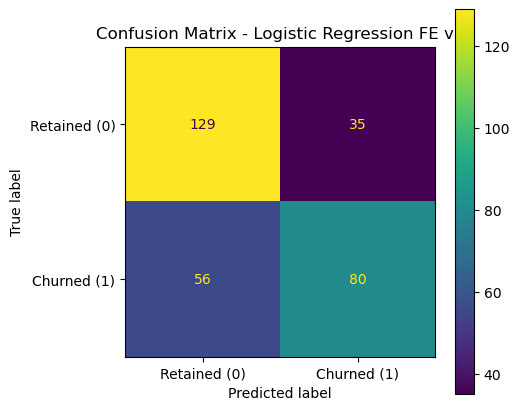

In [54]:
# Display confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))

ConfusionMatrixDisplay(
    confusion_matrix=lr_fe_v1_cm,
    display_labels=["Retained (0)", "Churned (1)"]
).plot(ax=ax)
ax.set_title("Confusion Matrix - Logistic Regression FE v1")

plt.show()

### Confusion Matrix Insights

The confusion matrix is unchanged relative to the baseline model.

The addition of missingness indicators did not alter classification decisions at the default threshold of 0.5.

This is consistent with the evaluation metrics, which show little practical performance improvement.

### Performance Comparison

In [55]:
comparison_metrics = pd.DataFrame({
    "Metric": [
        "ROC-AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Baseline": [
        lr_baseline_roc_auc,
        lr_baseline_accuracy,
        lr_baseline_precision,
        lr_baseline_recall,
        lr_baseline_f1
    ],
    "FE v1": [
        lr_fe_v1_roc_auc,
        lr_fe_v1_accuracy,
        lr_fe_v1_precision,
        lr_fe_v1_recall,
        lr_fe_v1_f1
    ]
})

comparison_metrics["Change"] = comparison_metrics["FE v1"] - comparison_metrics["Baseline"]

comparison_metrics[
    ["Baseline", "FE v1", "Change"]
] = comparison_metrics[
    ["Baseline", "FE v1", "Change"]
].round(3)

comparison_metrics

,Metric,Baseline,FE v1,Change
0,ROC-AUC,0.736,0.738,0.002
1,Accuracy,0.697,0.697,0.000
2,Precision,0.696,0.696,0.000
3,Recall,0.588,0.588,0.000
4,F1-Score,0.637,0.637,0.000


### Observations

- The addition of missingness indicators resulted in a marginal increase in ROC-AUC, from `0.736` to `0.738`.
- Accuracy, Precision, Recall, and F1-Score remained unchanged relative to the baseline model.
- The confusion matrix is identical to the baseline model, indicating that classification decisions were unaffected.
- For this dataset, missingness indicators provide little additional predictive information beyond the original feature set.
- This result highlights an important feature engineering principle: **every engineered feature should justify its inclusion through measurable performance improvements or improved business interpretability**.

### Feature Engineering Assessment

The missingness indicators were successfully incorporated into the modeling dataset and evaluated against the baseline model.

A small improvement in ROC-AUC was observed; however, all other evaluation metrics remained unchanged and the confusion matrix was identical to the baseline model.

These results suggest that missingness patterns contribute only limited additional predictive information for this dataset. This outcome is not uncommon, as missing values do not always correspond to meaningful behavioral differences between customers.

Although the performance improvement was minimal, the experiment remains valuable because it validates an important feature engineering hypothesis using empirical evidence rather than assumptions.

Future feature engineering efforts may focus on:

- customer lifecycle features
- billing-related derived features
- interaction features
- ratio-based features

All future modifications should be evaluated relative to the baseline model to determine whether they provide meaningful improvements in predictive performance.